ASTR8004 Assignment 2, Question 2

2.1 ADQL Query. Was unable to compute the join in the query, so this is as two separate parts, and joined together in python

In [15]:
#imports
from astroquery.gaia import Gaia
import numpy as np
import matplotlib.pyplot as plt

In [9]:
query_stage1 = """
SELECT
    gaia_filtered.source_id, gaia_filtered.ra, gaia_filtered.dec, gaia_filtered.phot_g_mean_mag,
    gaia_filtered.parallax, gaia_filtered.bp_rp,
    xmatch.original_ext_source_id
FROM
    (SELECT source_id, ra, dec, phot_g_mean_mag, parallax, bp_rp
     FROM gaiadr3.gaia_source
     WHERE CONTAINS(POINT('ICRS', ra, dec), CIRCLE('ICRS', 132.825, 11.800, 1)) = 1
     AND phot_g_mean_mag < 14
    ) AS gaia_filtered
JOIN
    gaiadr3.tmass_psc_xsc_best_neighbour AS xmatch
    ON gaia_filtered.source_id = xmatch.source_id
"""

job1 = Gaia.launch_job_async(query_stage1)
stage1_results = job1.get_results().to_pandas()
print("Stage 1 rows:", len(stage1_results))
print(stage1_results.columns.tolist())

INFO: Query finished. [astroquery.utils.tap.core]
Stage 1 rows: 1018
['source_id', 'ra', 'dec', 'phot_g_mean_mag', 'parallax', 'bp_rp', 'original_ext_source_id']


In [10]:
tmass_ids = stage1_results['original_ext_source_id'].dropna().astype(str).tolist()
id_list_str = ",".join(f"'{i}'" for i in tmass_ids)

query_2mass = f"""
SELECT designation, j_m, h_m, ks_m, ph_qual
FROM gaiadr1.tmass_original_valid
WHERE designation IN ({id_list_str})
"""

job2 = Gaia.launch_job_async(query_2mass)
tmass_results = job2.get_results().to_pandas()
print("2MASS rows:", len(tmass_results))

INFO: Query finished. [astroquery.utils.tap.core]
2MASS rows: 1013


In [11]:
final = stage1_results.merge(
    tmass_results, left_on='original_ext_source_id', right_on='designation'
)

print("Final crossmatched star count:", len(final))

print(f"Number of matched stars: {len(final)}")

Final crossmatched star count: 1018
Number of matched stars: 1018


2.2 

In [12]:
print(final['ph_qual'].value_counts())

ph_qual
AAA    997
UAA      5
AUA      2
AAE      2
EEE      2
AAF      2
DCD      1
ADA      1
DAD      1
AEA      1
UUA      1
UAE      1
UAU      1
UUE      1
Name: count, dtype: int64


In [13]:
good_photometry = final['ph_qual'] == 'AAA'
good_parallax = final['parallax'] > 0

clean = final[good_photometry & good_parallax]

print(f"Stars before cuts: {len(final)}")
print(f"Stars with ph_qual == 'AAA': {good_photometry.sum()}")
print(f"Stars with parallax > 0: {good_parallax.sum()}")
print(f"Stars remaining after both cuts: {len(clean)}")
print(f"Number of stars after quality cuts: {len(clean)}")

Stars before cuts: 1018
Stars with ph_qual == 'AAA': 997
Stars with parallax > 0: 1009
Stars remaining after both cuts: 988
Number of stars after quality cuts: 988


Starting from 1018 Gaia-2Mass crossmatched stars, two quality cuts were applied, removing stars with ph.qual not equal to AAA, and requiring positive Gaia parallax. This left 988 stars. 

2.3

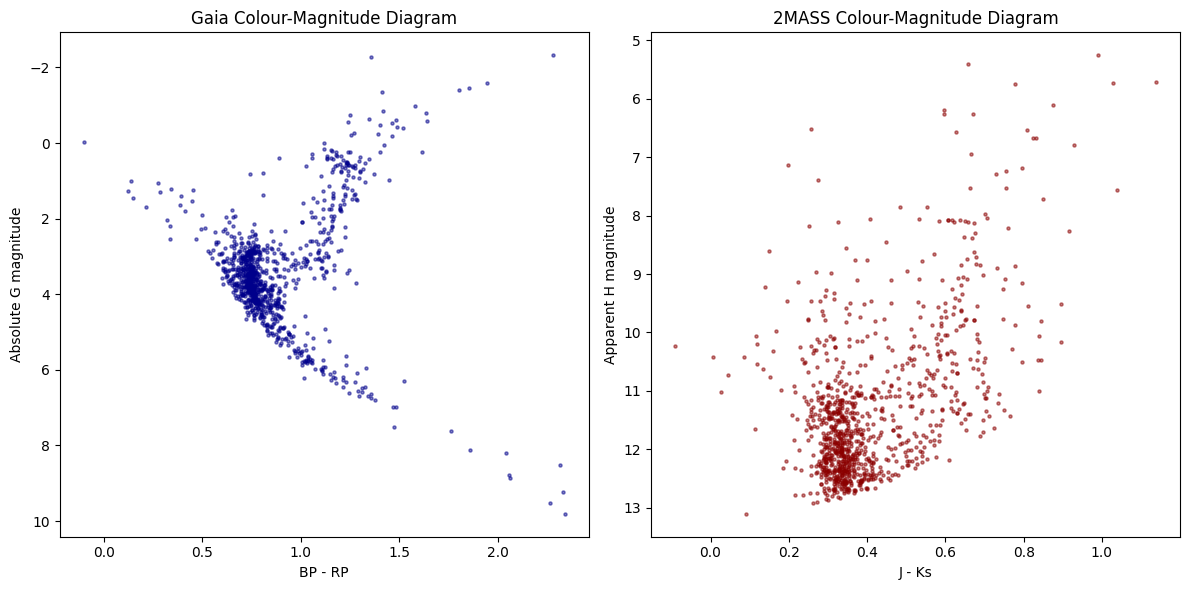

In [17]:
#Compute absolute G magnitude

distance_pc = 1000 / clean['parallax']
abs_g_mag = clean['phot_g_mean_mag'] - 5 * np.log10(distance_pc) + 5


#Compute J-K colour
j_minus_ks = clean['j_m'] - clean['ks_m']

#plot figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

#a) colour-magnitude diagram from Gaia data
ax1.scatter(clean['bp_rp'], abs_g_mag, s=5, alpha=0.5, color='darkblue')
ax1.set_xlabel('BP - RP')
ax1.set_ylabel('Absolute G magnitude')
ax1.invert_yaxis()   # brighter stars (smaller magnitude)  appear higher
ax1.set_title('Gaia Colour-Magnitude Diagram')

#b) colour-magnitude diagram from 2MASS data
ax2.scatter(j_minus_ks, clean['h_m'], s=5, alpha=0.5, color='darkred')
ax2.set_xlabel('J - Ks')
ax2.set_ylabel('Apparent H magnitude')
ax2.invert_yaxis()
ax2.set_title('2MASS Colour-Magnitude Diagram')

plt.tight_layout()
plt.savefig("figures/2_3_colour_mag.png", dpi=300)
plt.show()


The Gaia colour-mag diagram shows a well defined typical main sequence. The 2Mass diagram (right), uses apparent magnitude instead of absolute magnitude, and has a relatively consistent structure, with a bright population above the main clump of fainter stars.

2.4
2dF can position 392 fibres across a 2deg field for spectroscopic observations. This field was a 1deg radius cone around M37 - i.e. a 2deg diameter field, which is similar to 2dF's field of view. 

In [18]:
n_fibres = 392
n_targets = len(clean)

ratio = n_targets / n_fibres
print(f"Targets per fibre: {ratio:.2f}")
print (f"Number of targets: {n_targets}", f"Number of fibres: {n_fibres}")

Targets per fibre: 2.52
Number of targets: 988 Number of fibres: 392
